# Logistic Regression

In [1]:
# Data Handling and Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

###
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

###
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




In [2]:
# Read csv file and look at contents
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(file_path, sep=";", na_values=["", " ", "NA", "N/A", "nan", "NaN"])

print(df.shape)
print(df.head())

# Proportions of classes
print("Value Counts (in %):")
class_shares = df["OUTCOME_3Kat_KHK"].value_counts(normalize=True) * 100
print(class_shares.round(2))
print("Number of nan")
print(df.isnull().sum())
df.isnull().sum().sort_values(ascending=False).head(20)

# Gesamtanzahl leerer Zellen im gesamten DataFrame
print("Gesamtanzahl Zellen:", df.size)
print("Gesamtanzahl leerer Zellen:", df.isnull().sum().sum())

(2310, 649)
   OUTCOME_3Kat_KHK           Alter_0  geschlecht waist_0             WHR_0  \
0                 2  56,9691991786448           0     112  ,982456140350877   
1                 2  69,4976043805613           0     104              1,04   
2                 2  72,0492813141684           0     129  ,941605839416058   
3                 2  70,8145106091718           0      99  ,876106194690266   
4                 2  62,1601642710472           1     125               NaN   

              BMI_0  currsmo0  RR_syst_0  RR_diast_0  Pulse_Pressure  ...  \
0  32,8731097961867         0      130.0        80.0            50.0  ...   
1  30,1102788964583         0      160.0        70.0            90.0  ...   
2  44,7348800491207         0      140.0        90.0            50.0  ...   
3  26,2595847484332         0      130.0        90.0            40.0  ...   
4  42,4366343891054         1      180.0       100.0            80.0  ...   

   SMC231l  SMC232l  SMC233l  SMC240l  SMC241l SMC

/var/folders/rp/sz_1shj9783116jtrj1kc04m0000gn/T/ipykernel_27132/2271635866.py:3: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=";", na_values=["", " ", "NA", "N/A", "nan", "NaN"])


# 2.1 Logistic Regression

## First Try

In [3]:

# 2. Features (X) and target (y)
X = df.drop("OUTCOME_3Kat_KHK", axis=1)
y = df["OUTCOME_3Kat_KHK"]

# 3. Encode categorical features if any
X = pd.get_dummies(X, drop_first=True)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Train multinomial logistic regression model
model = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    solver="lbfgs"
)
model.fit(X_train, y_train)

# 6. Predictions
y_pred = model.predict(X_test)

# 7. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Accuracy  
Sounds alright, but we know that **class 2 makes up 57% of the data**.  
Our model isn’t better than a simple **“always class 2” predictor**.  

---

### Confusion Matrix  

Class 0 – *No Stenosis* (15.7% of Data)  
- Of the 73 real cases, only **9** are recognized correctly.  
- **45** are incorrectly categorized as class 2.  

Class 1 – *Light Stenosis* (27% of Data)  
- **29 of 126** correct → recall **23%**.  
- Most real class-1 cases are also categorized as class 2.  

Class 2 – *Stenosis* (57% of Data)  
- **220 of 263** correct → recall **84%**.  
- Most misclassifications are confused with class 1.  


## SECOND TRY

In [4]:

# 1. Load data
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(file_path, sep=";")


# 2. Features (X) and target (y)
X = df.drop("OUTCOME_3Kat_KHK", axis=1)
y = df["OUTCOME_3Kat_KHK"]

# 3. Encode categorical features if any
X = pd.get_dummies(X, drop_first=True)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Train multinomial logistic regression model with BALANCED CLASS WEIGHTS
model = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    solver="lbfgs",
    class_weight="balanced"   # NEW MEASURE: This should balance the classes
)
model.fit(X_train, y_train)

# 6. Predictions
y_pred = model.predict(X_test)

# 7. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.5324675324675324

Confusion Matrix:
 [[ 10  22  41]
 [  8  36  82]
 [ 16  47 200]]

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.14      0.19        73
           1       0.34      0.29      0.31       126
           2       0.62      0.76      0.68       263

    accuracy                           0.53       462
   macro avg       0.42      0.39      0.39       462
weighted avg       0.49      0.53      0.50       462



## THIRD TRY

/var/folders/rp/sz_1shj9783116jtrj1kc04m0000gn/T/ipykernel_27132/133986568.py:19: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regress

Accuracy: 0.43073593073593075

Confusion Matrix:
 [[ 40  16  17]
 [ 41  40  45]
 [ 87  57 119]]

Classification Report:
               precision    recall  f1-score   support

           0       0.24      0.55      0.33        73
           1       0.35      0.32      0.33       126
           2       0.66      0.45      0.54       263

    accuracy                           0.43       462
   macro avg       0.42      0.44      0.40       462
weighted avg       0.51      0.43      0.45       462



/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 1


ROC AUC — micro: 0.621, macro: 0.604
Avg Precision — micro: 0.423, macro: 0.407


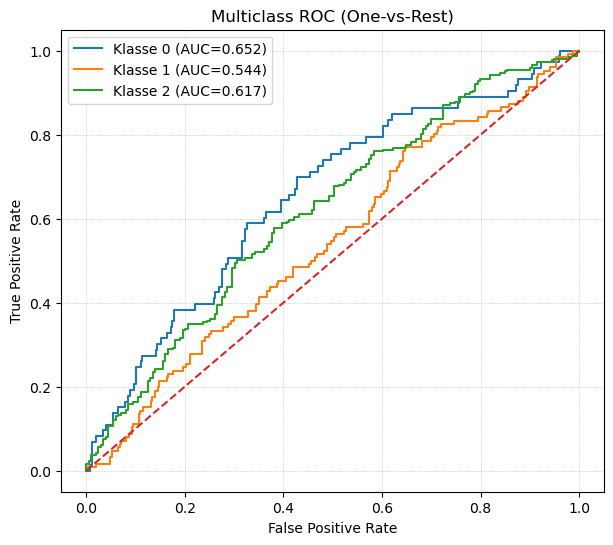

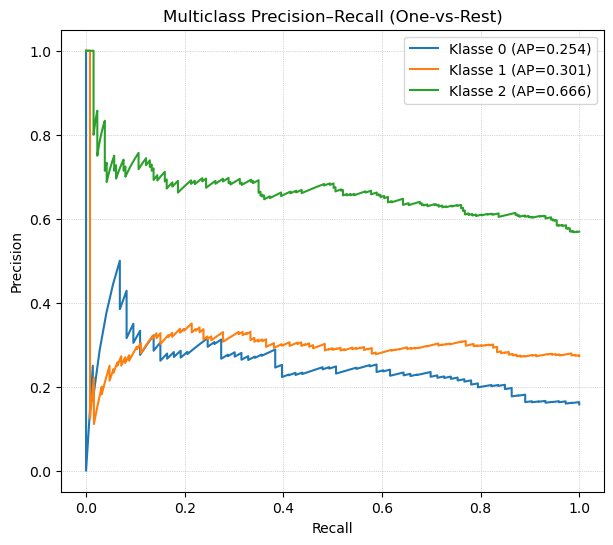


Top 15 features by missingness (%):
LTB4            99.70
PGE2            98.79
PGD2            98.79
PGaaC362l       98.48
@9SHODE         97.62
PGaaC361l       97.62
PGaaC341l       97.45
@15SHETE        96.15
@12SHETE        95.37
OAA_energy_m    93.25
OHKynurenine    93.12
PCaaC384        93.07
PCaaC364        93.07
PCaaC322        93.07
PCaaC323        93.07
dtype: float64


In [5]:
# Logistic Regression with proper NaN handling + imputation + OHE in a Pipeline
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1) Load data and treat empty strings etc. as NaN
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None]
)

# 2) Split features/target (no manual get_dummies here; pipeline handles encoding)
target_col = "OUTCOME_3Kat_KHK"
X = df.drop(columns=[target_col])
y = df[target_col]

# 3) Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Preprocessing:
#    - Numeric: median imputation
#    - Categorical: most-frequent imputation -> cast to string -> OneHotEncoder
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("to_str", FunctionTransformer(lambda X: X.astype(str))),  # unify types
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
])

# Select columns by dtype
numeric_features = selector(dtype_include=np.number)(X_train)
categorical_features = selector(dtype_exclude=np.number)(X_train)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# 5) Model: multinomial logistic regression with class weighting
logreg = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    solver="lbfgs",
    class_weight="balanced"
)

# 6) Full pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("logreg", logreg)
])

# 7) Fit
clf.fit(X_train, y_train)

# 8) Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Wahrscheinlichkeiten holen
y_score = clf.predict_proba(X_test)

# Klassen in der vom Modell verwendeten Reihenfolge
classes = clf.named_steps["logreg"].classes_  # z.B. array([0, 1, 2])
y_test_bin = label_binarize(y_test, classes=classes)

# Container
fpr, tpr, roc_auc = {}, {}, {}
precision, recall, avg_precision = {}, {}, {}

valid_classes_roc = []
valid_classes_pr = []

# Pro Klasse (OvR). Klassen ohne Positives im Testskippen, um Fehler zu vermeiden.
for i, c in enumerate(classes):
    y_true_i = y_test_bin[:, i]
    y_score_i = y_score[:, i]

    # ROC nur sinnvoll, wenn es Positives und Negatives gibt
    if y_true_i.any() and (~y_true_i.astype(bool)).any():
        fpr[i], tpr[i], _ = roc_curve(y_true_i, y_score_i)
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid_classes_roc.append(i)

    # PR-Kurve: braucht mind. ein Positives
    if y_true_i.any():
        precision[i], recall[i], _ = precision_recall_curve(y_true_i, y_score_i)
        avg_precision[i] = average_precision_score(y_true_i, y_score_i)
        valid_classes_pr.append(i)

# Micro/Macro
# (funktioniert auch, wenn einzelne Klassen im Testset fehlen)
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
avg_precision["micro"] = average_precision_score(y_test_bin, y_score, average="micro")

# Macro als Mittel der vorhandenen OvR-Skoren
if valid_classes_roc:
    roc_auc["macro"] = float(np.mean([roc_auc[i] for i in valid_classes_roc]))
else:
    roc_auc["macro"] = np.nan

if valid_classes_pr:
    avg_precision["macro"] = float(np.mean([avg_precision[i] for i in valid_classes_pr]))
else:
    avg_precision["macro"] = np.nan

print(f"\nROC AUC — micro: {roc_auc['micro']:.3f}, macro: {roc_auc['macro']:.3f}")
print(f"Avg Precision — micro: {avg_precision['micro']:.3f}, macro: {avg_precision['macro']:.3f}")

# --- ROC plot ---
plt.figure(figsize=(7, 6))
for i in valid_classes_roc:
    plt.plot(fpr[i], tpr[i], label=f"Klasse {classes[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (One-vs-Rest)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()

# --- Precision–Recall plot ---
plt.figure(figsize=(7, 6))
for i in valid_classes_pr:
    plt.plot(recall[i], precision[i], label=f"Klasse {classes[i]} (AP={avg_precision[i]:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall (One-vs-Rest)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()


# Optional: quick missingness report (after correct NaN parsing)
missing_pct = (X.isna().mean()*100).sort_values(ascending=False)
print("\nTop 15 features by missingness (%):")
print(missing_pct.head(15).round(2))


## FOURTH TRY

Dropping 548 columns with >95% missingness
Detected numeric features: 100
Detected categorical features: 0
Accuracy: 0.6320346320346321

Confusion Matrix:
 [[126  73]
 [ 97 166]]

Classification Report:
               precision    recall  f1-score   support

           0      0.565     0.633     0.597       199
           1      0.695     0.631     0.661       263

    accuracy                          0.632       462
   macro avg      0.630     0.632     0.629       462
weighted avg      0.639     0.632     0.634       462


ROC AUC: 0.701
Average Precision (AP): 0.750


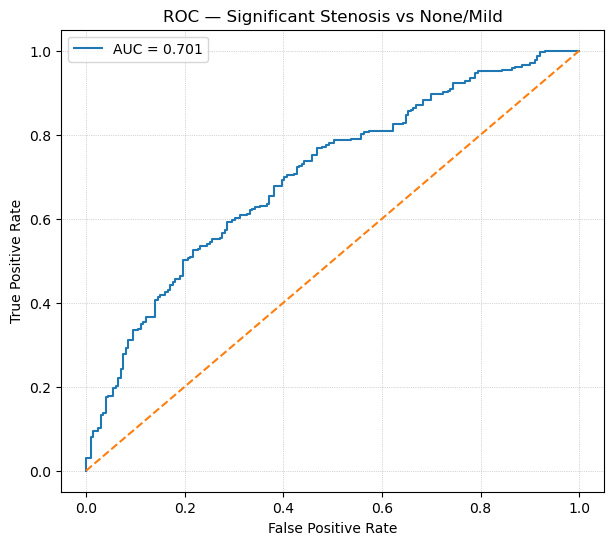

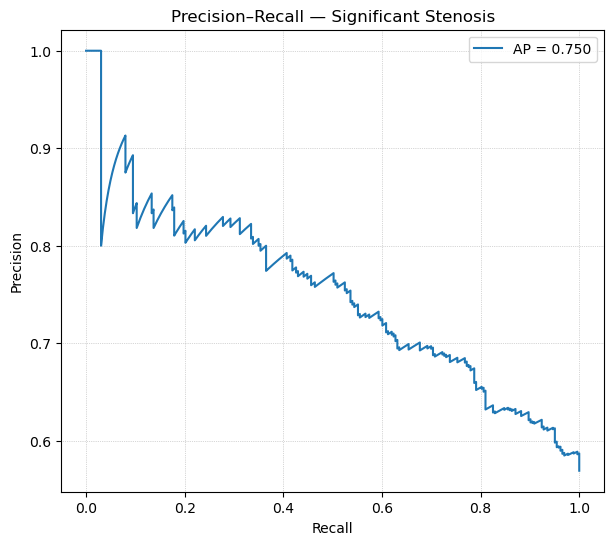


Top 15 features by missingness (%):
ProBNP_0                       67.45
GPC4_alle                      66.19
PHOSPHAT                       64.59
FGF23                          64.55
CALCIUM                        64.46
HGmax                          63.42
oxLDL                          63.25
NEUT_ABS_gesamt                61.26
LYMP_ABS_gesamt                61.21
Klotho                         61.08
VitaminD                       60.30
Cer_d18_24_1_I_Cer_d18_24_0    60.26
Cer_d18_18_I_Cer_d18_24_0      60.26
Cer_d18_16_I_Cer_d18_24_0      60.26
Cer_d18_16                     60.22
dtype: float64

Class balance (0=none/mild, 1=significant):
OUTCOME_3Kat_KHK
1    0.569
0    0.431
Name: proportion, dtype: float64


In [6]:
# Logistic Regression (Binary) with NaN handling + imputation + OHE + StandardScaler in a Pipeline
# Binary target: 1 = significant stenosis (orig. class 2), 0 = none/mild (orig. classes 0 or 1)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, confusion_matrix, classification_report
)

# 1) Load data with correct decimal separator and NaN parsing
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",  # <<< Important: fixes numeric commas
    na_values=["", " ", "NA", "N/A", "NaN", "nan"],
    low_memory=False
)

# 2) Try converting object columns that actually contain numbers
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    cand = s.str.replace(",", ".", regex=False)
    num = pd.to_numeric(cand, errors="coerce")
    if num.notna().mean() >= 0.8:  # if at least 80% are numeric
        df[c] = num

# Remove columns with >95% missing values
missing_ratio = df.isna().mean()
drop_cols = missing_ratio[missing_ratio > 0.75].index
print(f"Dropping {len(drop_cols)} columns with >95% missingness")
df = df.drop(columns=drop_cols)


# 3) Define binary target: 1 = significant stenosis (class 2), 0 = none/mild (classes 0 or 1)
target_col = "OUTCOME_3Kat_KHK"
y_multi = df[target_col]
y = (y_multi == 2).astype(int)
X = df.drop(columns=[target_col])

# 4) Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Identify low-cardinality categorical features only
non_num = X_train.select_dtypes(exclude=np.number)
low_card_mask = non_num.nunique() <= 30  # only keep columns with <=30 unique values
categorical_features = low_card_mask[low_card_mask].index.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"Detected numeric features: {len(numeric_features)}")
print(f"Detected categorical features: {len(categorical_features)}")

# 6) Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("to_str", FunctionTransformer(lambda X: X.astype(str))),
    ("onehot", make_ohe())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# 7) Logistic Regression (balanced for class skew)
logreg = LogisticRegression(max_iter=5000, solver="lbfgs", class_weight="balanced")

# 8) Full pipeline
clf = Pipeline(steps=[("preprocess", preprocess), ("logreg", logreg)])

# 9) Fit
clf.fit(X_train, y_train)

# 10) Evaluate
y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Precision–Recall
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)

print(f"\nROC AUC: {roc_auc:.3f}")
print(f"Average Precision (AP): {avg_precision:.3f}")

# --- ROC plot ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Significant Stenosis vs None/Mild")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()

# --- Precision–Recall plot ---
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Significant Stenosis")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()

# Optional diagnostics
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
print("\nTop 15 features by missingness (%):")
print(missing_pct.head(15).round(2))

print("\nClass balance (0=none/mild, 1=significant):")
print(y.value_counts(normalize=True).round(3))


In [7]:
import pandas as pd
import numpy as np

file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(file_path, sep=";", na_values=["", " ", "NA", "N/A", "NaN", "nan"], low_memory=False)

print(df.shape)
print(df.dtypes.value_counts())
print("Anzahl numerischer Spalten:", df.select_dtypes(include=np.number).shape[1])
print("Anzahl nicht-numerischer Spalten:", df.select_dtypes(exclude=np.number).shape[1])

print("Train AUC:", roc_auc_score(y_train, clf.predict_proba(X_train)[:,1]))
print("Test AUC:", roc_auc_score(y_test, clf.predict_proba(X_test)[:,1]))



(2310, 649)
object     602
float64     43
int64        4
Name: count, dtype: int64
Anzahl numerischer Spalten: 47
Anzahl nicht-numerischer Spalten: 602
Train AUC: 0.74116781626765
Test AUC: 0.7012438618950265
